# Writing Your Own Mesh

A mesh supplies only its geometry and how it is held and loaded. `MeshBase` derives
everything else from that: the free degree of freedom bookkeeping, the load vector,
the shape sensitivities, and the checks that catch a mesh that would give a wrong
answer rather than an error. The contract is one method and a handful of calls:

| | |
|---|---|
| `Build(...)` | the one method you write |
| `SetNodes(Nodes)` | `(NumNodes, 3)` of `[id, x, y]`, ids running 1 to NumNodes |
| `SetElements(Connectivity)` | one based node ids, `NumNodes` wide |
| `Fix(Nodes, 'x' \| 'y' \| 'xy')` | boundary conditions by node id, with `Pin`, `Clamp` and `Free` on top |
| `AddLoad(Nodes, Vector)` | a force vector at any set of nodes, accumulating |
| `SetSensitivity(Rebuild, Variables)` | shape derivatives, by finite differencing the mesher itself |
| `_Finalise()` | defaults the load path probe and validates |

Two helpers do most of the geometry: `_GridNodes` stacks rows of nodes into the array
`SetNodes` wants, and `_StripElements` walks one element's node numbering along a strip.

The mesh built below is a tapered cantilever. It has two shape variables, the height at
the root and the height at the tip, and every node moves with both of them, so the
sensitivities are not trivially zero anywhere.


In [1]:
import contextlib
import logging
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np

from fem2d.meshers import Mesh, MeshBase, MeshWarning
from fem2d.postprocessing import Plotting
from fem2d.solvers import LinearSolver, NonLinearSolver

logging.basicConfig(level=logging.INFO, format='%(message)s', stream=sys.stdout)
SolverLog = logging.getLogger('fem2d.solvers')


@contextlib.contextmanager
def quiet():
    # Silence the solver progress log.
    SolverLog.setLevel(logging.WARNING)
    try:
        yield
    finally:
        SolverLog.setLevel(logging.NOTSET)


E, v, t, plane = 210000.0, 0.3, 1.0, 1

## The geometry

Two rows of nodes, `el_num + 1` in each, the bottom one flat on $y = 0$ and the top one
sloping from `RootHeight` down to `TipHeight`. Numbering runs left to right along the
bottom row first and then along the top, so element $i$ is

$$[\, i+1,\; i+2,\; i + \texttt{el\_num} + 3,\; i + \texttt{el\_num} + 2 \,]$$

which is one first node and one increment, exactly what `_StripElements` takes.

The corner order matters. It has to run counter clockwise, bottom left, bottom right,
top right, top left, or the Jacobian is negative throughout the element and its
contribution to the stiffness comes out with the wrong sign. Nothing downstream would
complain; the answer would just be wrong. `Validate` is what catches it, and the next
section breaks it deliberately to show that.


In [2]:
class TaperedBeam(MeshBase):
    '''A cantilever whose height varies linearly from the root to the tip.'''

    def _NodeArray(self, el_num, Length, RootHeight, TipHeight):
        # Two rows: the bottom flat, the top tapering. _GridNodes stacks them and
        # numbers them, so a row is just an (X, Y) pair.
        X = np.linspace(0, Length, el_num + 1)
        Top = np.linspace(RootHeight, TipHeight, el_num + 1)

        return self._GridNodes([(X, 0.0), (X, Top)])

    def Build(self, el_num, Length, RootHeight, TipHeight, Load):
        self.SetNodes(self._NodeArray(el_num, Length, RootHeight, TipHeight))
        self.SetElements(self._StripElements([1, 2, el_num + 3, el_num + 2],
                                             [1, 1, 1, 1], el_num))

        # Clamp the whole root edge, load the top corner of the tip downwards.
        self.Clamp([1, el_num + 2])
        self.AddLoad(2*el_num + 2, [0.0, Load])

        # Differentiate the node positions w.r.t the two heights. Rebuilding the
        # mesh is the whole rule; SetSensitivity does the finite differencing and
        # sets VariableNumber to match.
        self.SetSensitivity(lambda Var: self._NodeArray(el_num, Length, *Var),
                            [RootHeight, TipHeight])

        self._Finalise()

        return

That is the whole mesh. Everything below it is inherited.

## Does it hold together?

`_Finalise` has already run `Validate`, so reaching this point at all means the
connectivity matches the element, the node numbering lines up with how the solvers
index it, and every element is the right way round.


26 nodes, 12 elements
held dof:  [ 0  1 26 27]
loaded dof: [51], values [-25.]
probe dof:  51  (LoadNode is the same thing: 51)
free dof:   48 of 52


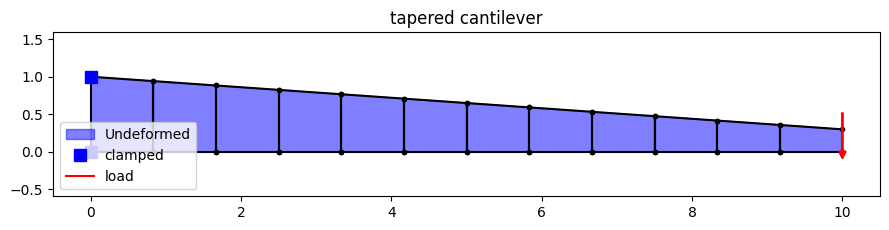

In [3]:
Beam = TaperedBeam(E, v, t, plane, 'Q4')
Beam.Build(el_num=12, Length=10.0, RootHeight=1.0, TipHeight=0.3, Load=-25.0)

print(f'{Beam.Nodes.shape[0]} nodes, {Beam.Elements.shape[0]} elements')
print(f'held dof:  {Beam.HeldDOF}')
print(f'loaded dof: {Beam.LoadDOF}, values {Beam.Load[Beam.LoadDOF, 0]}')
print(f'probe dof:  {Beam.ProbeDOF}  (LoadNode is the same thing: {Beam.LoadNode})')
print(f'free dof:   {Beam.DegOfFreedom.size} of {Beam.Nodes.shape[0]*2}')

fig, ax = plt.subplots(figsize=(9, 2.4))
Plotting.InitialMesh(Beam, ax=ax)

Held = np.unique(Beam.HeldDOF//2)
ax.plot(Beam.Nodes[Held, 1], Beam.Nodes[Held, 2], 'bs', ms=9, label='clamped')

Probe = Beam.ProbeDOF//2
ax.annotate('', xy=(Beam.Nodes[Probe, 1], Beam.Nodes[Probe, 2] - 0.45),
            xytext=(Beam.Nodes[Probe, 1], Beam.Nodes[Probe, 2] + 0.25),
            arrowprops=dict(arrowstyle='-|>', color='r', lw=2))
ax.plot([], [], 'r-', label='load')
ax.legend(loc='lower left')
ax.set_title('tapered cantilever')
plt.tight_layout()

## What `Validate` checks

Two kinds of problem. Things that would give a **wrong answer** are errors, raised
together so a broken mesh reports everything at once. Things that are legitimate in
some mesh but are usually a mistake are `MeshWarning`s, which do not stop the build.

Three deliberate breakages, one of each of the failures that actually happen:


In [4]:
def Broken(Break, ElementType='Q4'):
    # Build a valid mesh with the checks off, break it, then ask for the verdict.
    m = TaperedBeam(E, v, t, plane, ElementType)
    m.AutoValidate = False
    m.Build(el_num=12, Length=10.0, RootHeight=1.0, TipHeight=0.3, Load=-25.0)

    Break(m)

    try:
        with warnings.catch_warnings(record=True) as Caught:
            warnings.simplefilter('always')
            m.Validate()
        for w in Caught:
            print(f'warning: {w.message}')
    except ValueError as Err:
        print(Err)

    print()


# 1. Corner nodes the wrong way round. This is the one that used to pass silently
#    and flip the sign of the element stiffness.
Broken(lambda m: m.Elements.__setitem__((3, slice(1, None)), m.Elements[3, 1:][::-1]))

# 2. A four node connectivity handed to an eight node element. This is exactly the
#    bug Q8Mesh.LeeFrame shipped with before it had a mesher of its own.
Broken(lambda m: setattr(m, 'ElementType', 'Q8'))

# 3. A load applied where the mesh is clamped, so it is silently discarded.
Broken(lambda m: m.AddLoad(1, [0.0, -25.0]))

This mesh is not valid:
  Elements [4] have their corner nodes in clockwise order. The Jacobian is then negative throughout, which flips the sign of their contribution to the stiffness and gives a plausible looking but wrong answer. Reverse the node order in those rows.

This mesh is not valid:
  Elements has 5 columns but element type 'Q8' has 8 nodes, so it needs 9: an id column and one column per node.




The escape hatch is `AutoValidate = False`, as used above, or editing the arrays
in place and calling `Validate()` when you are ready. `Validate(Jacobian=True)` adds a
stricter check: it instantiates the element and requires a positive Jacobian at every
Gauss point, which catches a mid side node placed badly enough to fold the mapping,
something the corner check cannot see.

## It solves

Nothing in the solvers knows this mesh is new.


tip deflection, small strain: -0.56575
tip deflection, large:        -0.56366


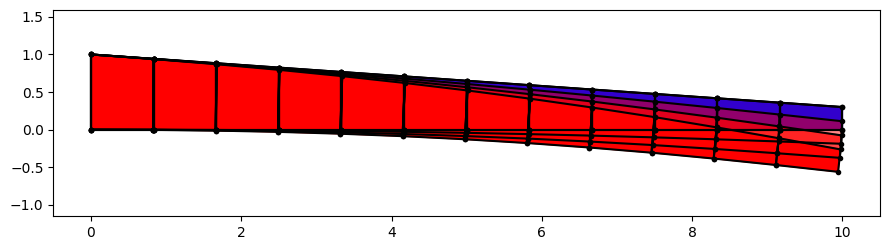

In [5]:
with quiet():
    LinearSolver(Beam).Solve()
    Linear = float(Beam.U[Beam.ProbeDOF, 0])

    Large = TaperedBeam(E, v, t, plane, 'Q4')
    Large.Build(el_num=12, Length=10.0, RootHeight=1.0, TipHeight=0.3, Load=-25.0)
    NonLinearSolver(Large, LoadSteps=3, tol=1e-8, MaxIter=30).Solve()

print(f'tip deflection, small strain: {Linear:.5f}')
print(f'tip deflection, large:        {float(Large.U[Large.ProbeDOF, 0]):.5f}')

fig, ax = plt.subplots(figsize=(9, 2.6))
Plotting.Overlay(Large, ax=ax, steps=1)
plt.tight_layout()

## Sensitivities come free

`SetSensitivity` finite differences the mesher itself, so `dXdx` holds how every node
moves per unit change in each design variable. From there the solvers differentiate the
solve analytically. Writing the mesh was the only work; the gradient came with it.

Checked against a central difference of the whole solve, which is the honest test
because it goes through the mesher, the assembly and the factorisation together.


In [6]:
print(f'VariableNumber {Beam.VariableNumber}, dXdx {Beam.dXdx.shape} '
      f'(nodes x 2*variables)')

Design = [1.0, 0.3]


def TipDeflection(Var):
    m = TaperedBeam(E, v, t, plane, 'Q4')
    m.Build(el_num=12, Length=10.0, RootHeight=Var[0], TipHeight=Var[1], Load=-25.0)
    with quiet():
        LinearSolver(m).Solve()

    return float(m.U[m.ProbeDOF, 0])


m = TaperedBeam(E, v, t, plane, 'Q4')
m.Build(el_num=12, Length=10.0, RootHeight=Design[0], TipHeight=Design[1], Load=-25.0)
with quiet():
    LinearSolver(m, Sensitivity=True).Solve()

Analytic = m.dUdx[m.ProbeDOF, :]

Step = 1e-5
Central = np.array([(TipDeflection([D + (i == j)*Step for j, D in enumerate(Design)])
                     - TipDeflection([D - (i == j)*Step for j, D in enumerate(Design)]))/(2*Step)
                    for i in range(len(Design))])

print(f'{"variable":<12}{"analytic":>14}{"central FD":>14}{"rel err":>12}')
for Name, a, c in zip(('RootHeight', 'TipHeight'), Analytic, Central):
    print(f'{Name:<12}{a:>14.6e}{c:>14.6e}{abs(a - c)/abs(c):>12.1e}')

VariableNumber 2, dXdx (26, 4) (nodes x 2*variables)
variable          analytic    central FD     rel err
RootHeight    1.151586e+00  1.151586e+00     1.3e-07
TipHeight     7.409129e-01  7.409129e-01     3.8e-08


## Against a shipped mesh

With both heights equal the taper disappears and the geometry is exactly
`Mesh.SimpleBeam`. The answers still differ in the fifth digit, and the reason is worth
seeing: `SimpleBeam` does not clamp its root. It pins the bottom node and holds the top
one in $x$ only, leaving it free to slide vertically, so the root edge can still rotate.
Releasing that one degree of freedom with `Free` reproduces it to the last digit.

Then the taper is swept, and `Plotting.LoadPath` follows `ProbeDOF` through each solve
without being told anything about the mesh.


same nodes: True, same elements: True
TaperedBeam, clamped root:  -1.5812494416
TaperedBeam, rollered root: -1.5812978718
Mesh.SimpleBeam:            -1.5812978718
held dof, mine [ 0  1 26] vs shipped [ 0  1 26]


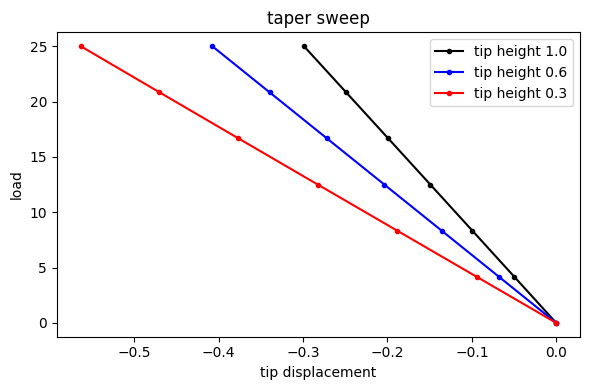

In [7]:
Flat = TaperedBeam(E, v, t, plane, 'Q4')
Flat.Build(el_num=12, Length=10.0, RootHeight=0.5, TipHeight=0.5, Load=-25.0)

Shipped = Mesh(E, v, t, plane, 'Q4')
Shipped.SimpleBeam(el_num=12, Length=10.0, Height=0.5, Load=-25.0)

# The same mesh again, but pinned the way SimpleBeam pins it.
Rollered = TaperedBeam(E, v, t, plane, 'Q4')
Rollered.Build(el_num=12, Length=10.0, RootHeight=0.5, TipHeight=0.5, Load=-25.0)
Rollered.Free(14, 'y')

with quiet():
    for m in (Flat, Shipped, Rollered):
        LinearSolver(m).Solve()

print(f'same nodes: {np.allclose(Flat.Nodes, Shipped.Nodes)}, '
      f'same elements: {np.array_equal(Flat.Elements, Shipped.Elements)}')
print(f'TaperedBeam, clamped root:  {float(Flat.U[Flat.ProbeDOF, 0]):.10f}')
print(f'TaperedBeam, rollered root: {float(Rollered.U[Rollered.ProbeDOF, 0]):.10f}')
print(f'Mesh.SimpleBeam:            {float(Shipped.U[Shipped.ProbeDOF, 0]):.10f}')
print(f'held dof, mine {Rollered.HeldDOF} vs shipped '
      f'{np.setdiff1d(np.arange(Shipped.Nodes.shape[0]*2), Shipped.DegOfFreedom)}')

fig, ax = plt.subplots(figsize=(6, 4))
for TipHeight, colour in zip((1.0, 0.6, 0.3), ('k', 'b', 'r')):
    m = TaperedBeam(E, v, t, plane, 'Q4')
    m.Build(el_num=12, Length=10.0, RootHeight=1.0, TipHeight=TipHeight, Load=-25.0)
    with quiet():
        NonLinearSolver(m, LoadSteps=6, tol=1e-8, MaxIter=30).Solve()
    Plotting.LoadPath(m, ax=ax, c=colour)

ax.legend([f'tip height {h}' for h in (1.0, 0.6, 0.3)])
ax.set(xlabel='tip displacement', ylabel='load', title='taper sweep')
plt.tight_layout()

## Summary

The mesh was a node array, a connectivity array, two boundary condition calls and one
load call. Out of that came the free degree of freedom set, the load vector, the shape
sensitivities, all three solvers, every plotting helper, and a set of checks that reject
the mistakes which would otherwise have shown up as a plausible wrong number.

`AddLoad` accumulates and takes a vector per node, so a distributed load is the same call
with more nodes and a `(k, 2)` array rather than anything new. `ProbeDOF` is only about
which curve the load path plots; it defaults to the largest applied component and
`SetProbe` overrides it. `LoadNode` is the older name for it, kept because the research
notebooks index the displacement history with it.

For a harder version of the same recipe, `Q8Mesh.LeeFrame` in `fem2d/meshers/eight_node.py`
is an L of two members meshed as one strip, with a mitred corner and eight nodes per
element. It is the same five calls, with `_StripNodes` building the three row layout the
eight node elements need.
